# Music Recommendation System

In [172]:
#%pip install scikit-learn
#%pip install pandas
#%pip install matplotlib.pyplot 
#%pip install seaborn 
#%pip install numpy 

In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

## Data Cleaning

In [174]:
# Load and prep data
df = pd.read_csv('data.csv')

print("Duplicate IDs:", df['id'].duplicated().sum())
print("Duplicate name+artist:", df.duplicated(subset=['name', 'artists']).sum())

Duplicate IDs: 0
Duplicate name+artist: 12968


In [175]:
df = df.sort_values('popularity', ascending=False)
df = df.drop_duplicates(subset=['name', 'artists'], keep='first')
print(f"After removing duplicates: {df.shape[0]:,} tracks")

After removing duplicates: 157,685 tracks


In [176]:
df = df[(df['tempo'] > 0) & (df['tempo'] <= 200)]
print(f"After tempo filter (0 < tempo ≤ 200): {df.shape[0]:,} tracks")

After tempo filter (0 < tempo ≤ 200): 156,344 tracks


In [177]:
df['instrumentalness_log'] = np.log1p(df['instrumentalness'])
print(f"Instrumentalness skew before: {df['instrumentalness'].skew():.3f}")
print(f"Instrumentalness skew after:  {df['instrumentalness_log'].skew():.3f}")

Instrumentalness skew before: 1.623
Instrumentalness skew after:  1.532


In [178]:
print(f"\nFinal dataset: {df.shape[0]:,} tracks")


Final dataset: 156,344 tracks


In [179]:
df = df.reset_index(drop=True)
print(f"Index reset. Shape: {df.shape}")

Index reset. Shape: (156344, 20)


In [180]:
test_features = [
    'danceability',
    'energy',
    'loudness',            
    'instrumentalness_log',
    'tempo',
    'valence',
    'acousticness',
]


## Data Mining Tasks

### Distribution Analysis

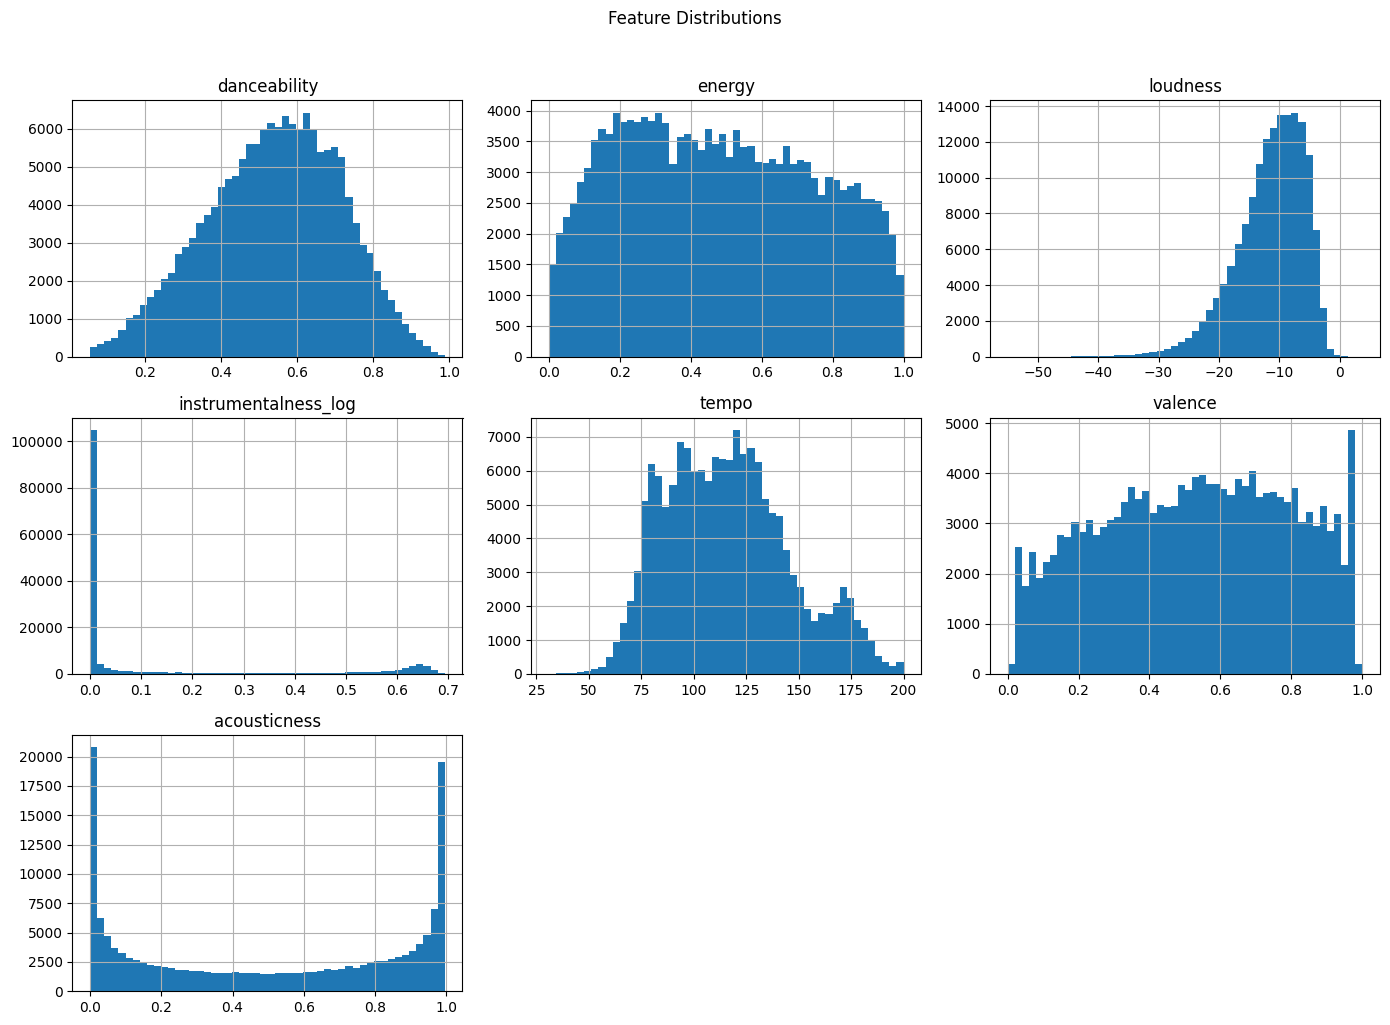

In [181]:
df[test_features].hist(bins=50, figsize=(14, 10))
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()

In [182]:
# Skewness summary
print(df[test_features].skew().sort_values(ascending=False))

instrumentalness_log    1.532013
tempo                   0.406369
energy                  0.123429
acousticness           -0.041739
valence                -0.097952
danceability           -0.218024
loudness               -1.009919
dtype: float64


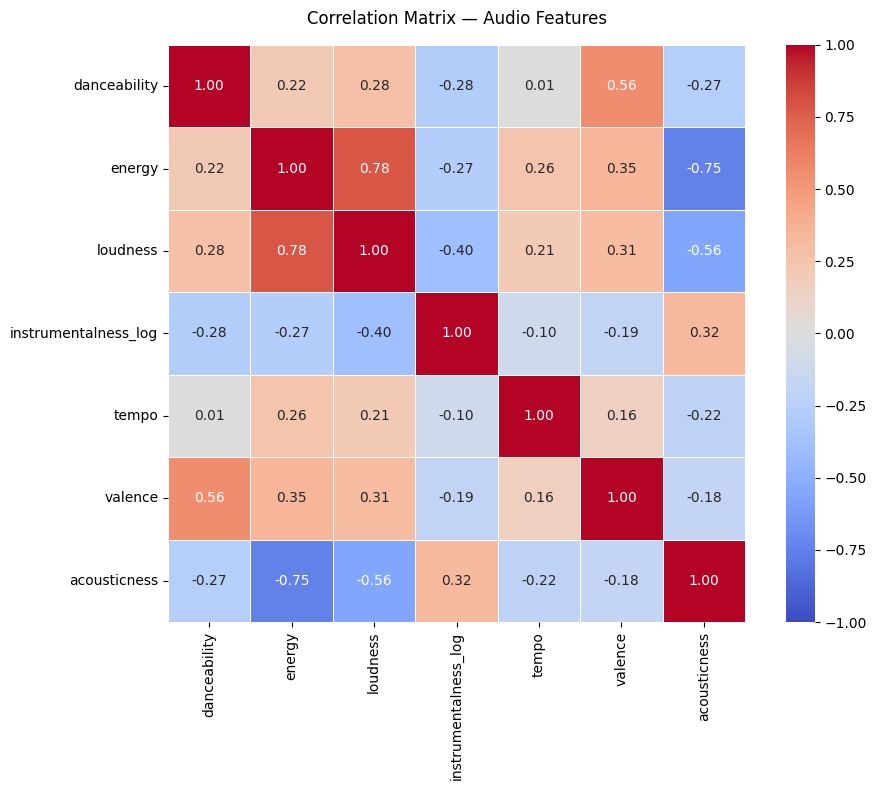

In [183]:
corr = df[test_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
)
plt.title('Correlation Matrix — Audio Features', pad=15)
plt.tight_layout()
plt.show()

In [184]:
# Drop loudness
features = [
    'danceability',
    'energy',
    'instrumentalness_log',
    'tempo',
    'valence',
    'acousticness'
]

### PCA

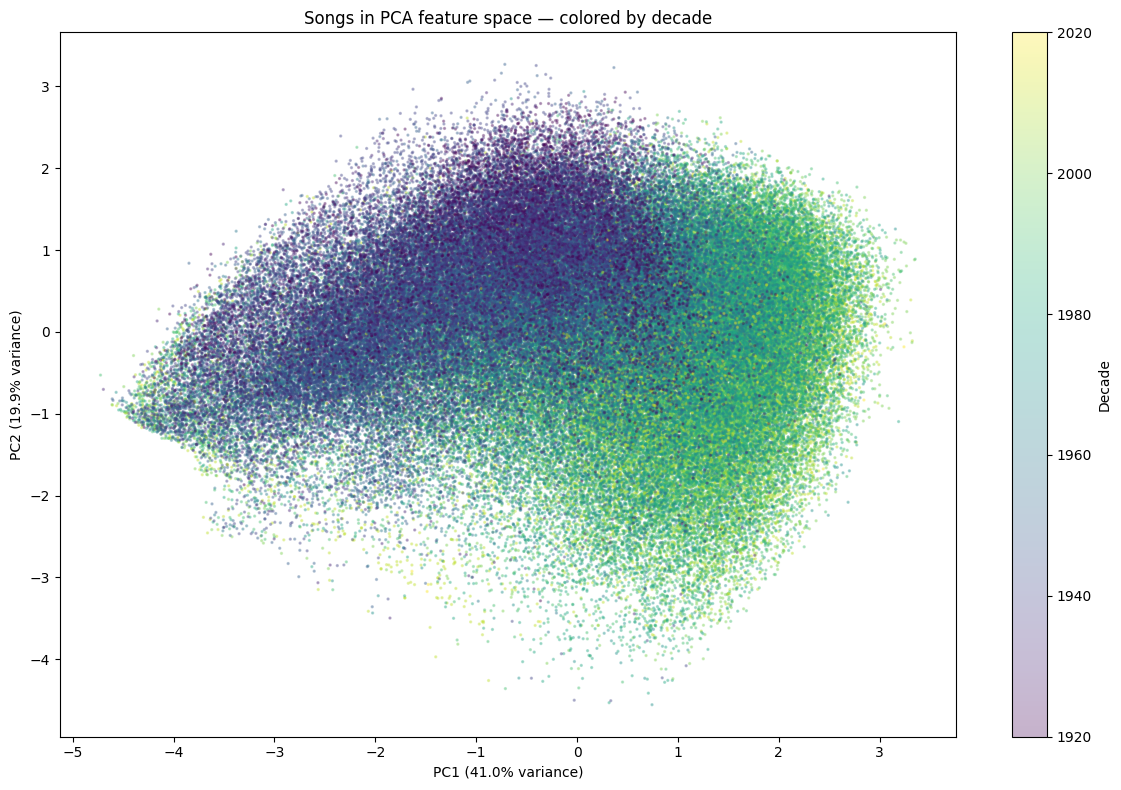

In [185]:
df['decade'] = (df['year'] // 10) * 10


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
decades = df['decade'].values
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=decades,
                      alpha=0.3, s=2,
                      cmap='viridis')
plt.colorbar(scatter, label='Decade')
plt.title('Songs in PCA feature space — colored by decade')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

In [186]:
print(f"PC1 explains: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

PC1 explains: 41.0%
PC2 explains: 19.9%
Total explained: 60.9%


### Optimal K Selection

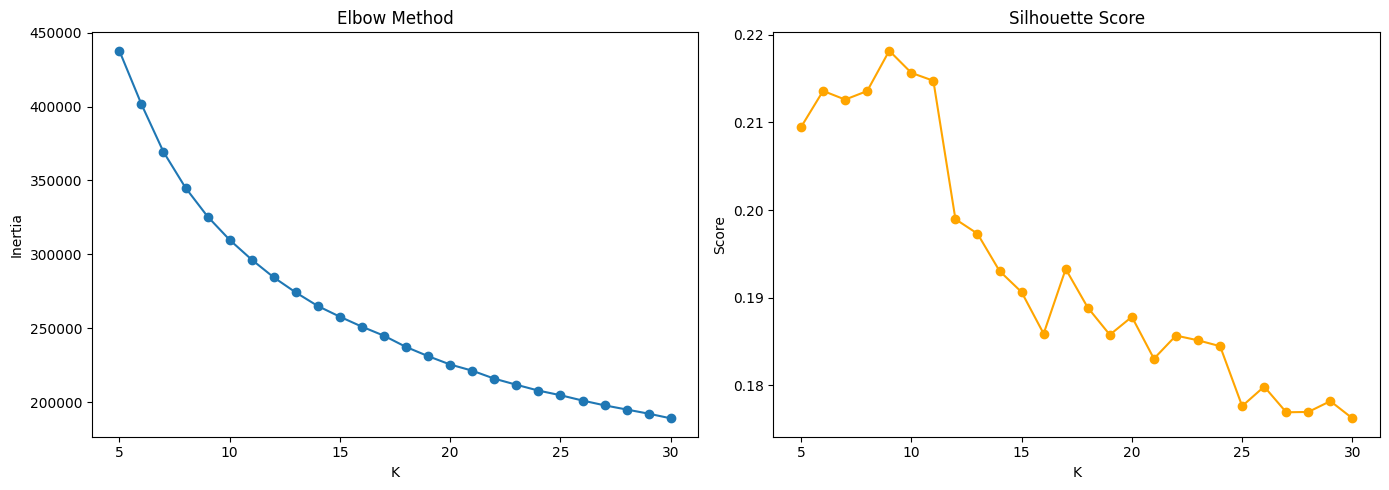

In [187]:
inertias = []
silhouette_scores = []
K_range = range(5, 31)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertias, marker='o')
ax1.set_title('Elbow Method'); ax1.set_xlabel('K'); ax1.set_ylabel('Inertia')
ax2.plot(K_range, silhouette_scores, marker='o', color='orange')
ax2.set_title('Silhouette Score'); ax2.set_xlabel('K'); ax2.set_ylabel('Score')
plt.tight_layout()

## Machine Learning

### K-Means Clustering

In [188]:
results = {}

for k in [9, 12, 15, 18, 20]:
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_test.fit_predict(X_scaled)
    
    sizes = pd.Series(labels).value_counts()
    ratio = sizes.max() / sizes.min()
    score = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    
    results[k] = {
        'silhouette': score,
        'max_cluster': sizes.max(),
        'min_cluster': sizes.min(),
        'ratio': ratio
    }
    
    print(f"K={k}: silhouette={score:.3f}, "
          f"max={sizes.max():,}, min={sizes.min():,}, ratio={ratio:.1f}x")


K=9: silhouette=0.218, max=29,394, min=6,292, ratio=4.7x
K=12: silhouette=0.199, max=20,901, min=6,005, ratio=3.5x
K=15: silhouette=0.191, max=17,493, min=5,413, ratio=3.2x
K=18: silhouette=0.189, max=13,260, min=3,315, ratio=4.0x
K=20: silhouette=0.188, max=13,338, min=3,224, ratio=4.1x


In [189]:
km = KMeans(n_clusters=12, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

# Check cluster sizes — should be reasonably balanced
print("Songs per cluster:")
print(df['cluster'].value_counts().sort_index())

Songs per cluster:
cluster
0     10352
1     20901
2     12718
3     11877
4     12888
5      9763
6     13024
7     13468
8     16756
9     15872
10     6005
11    12720
Name: count, dtype: int64


In [190]:
def recommend(song_name, df, X_scaled, n=10):
    matches = df[df['name'].str.lower().str.contains(
        song_name.lower(), na=False
    )]

    if matches.empty:
        print(f"'{song_name}' not found.")
        return None

    seed_row = matches.sort_values('popularity', ascending=False).iloc[0]
    seed_idx = seed_row.name

    print(f"Seed:    '{seed_row['name']}' by {seed_row['artists']} ({seed_row['year']})")
    print(f"Cluster: {seed_row['cluster']}")
    print(f"Profile: energy={seed_row['energy']:.2f}, "
          f"danceability={seed_row['danceability']:.2f}, "
          f"valence={seed_row['valence']:.2f}, "
          f"acousticness={seed_row['acousticness']:.2f}, "
          f"tempo={seed_row['tempo']:.0f}bpm")

    cluster_mask = (
        (df['cluster'] == seed_row['cluster']) &
        (df.index != seed_idx) &
        (~df['name'].str.lower().str.contains(song_name.lower(), na=False))
    )
    cluster_df = df[cluster_mask]
    print(f"Pool:    {len(cluster_df):,} songs in cluster {seed_row['cluster']}")

    seed_vector     = X_scaled[seed_idx].reshape(1, -1)
    cluster_vectors = X_scaled[cluster_df.index]
    similarities    = cosine_similarity(seed_vector, cluster_vectors)[0]

    top_n_pos   = similarities.argsort()[-n:][::-1]
    top_indices = cluster_df.index[top_n_pos]

    results = df.loc[top_indices,
                     ['name', 'artists', 'year', 'popularity'] + features].copy()
    results['similarity_score'] = similarities[top_n_pos].round(4)

    alpha = 0.3
    results['final_score'] = (
        results['similarity_score'] * (1 - alpha) +
        (results['popularity'] / 100) * alpha
    ).round(4)

    return results.sort_values('final_score', ascending=False).reset_index(drop=True)

In [191]:
# Test with a known song
recs = recommend("Bohemian Rhapsody", df, X_scaled, n=10)
if recs is not None:
    print(recs[['name', 'artists', 'year', 'similarity_score', 'final_score']])

Seed:    'Bohemian Rhapsody - Remastered 2011' by ['Queen'] (1975)
Cluster: 3
Profile: energy=0.40, danceability=0.39, valence=0.23, acousticness=0.29, tempo=144bpm
Pool:    11,875 songs in cluster 3
                                      name  \
0                              Tiny Dancer   
1                I Was Made For Loving You   
2                       Perfume a Tus Pies   
3                        I Loved Her First   
4                                 Exitlude   
5                          Spanish Caravan   
6                      She Talks to Angels   
7                       The Prophet's Song   
8  Three-Four vs. Six-Eight Four-Four Ways   
9           Where Did You Sleep Last Night   

                                  artists  year  similarity_score  final_score  
0                          ['Elton John']  1971            0.9875       0.9282  
1            ['Tori Kelly', 'Ed Sheeran']  2016            0.9867       0.8887  
2             ['En Espíritu Y En Verdad']  2007   

## Evaluation

### Feature Profile Divergence

In [192]:
def evaluate_feature_divergence(song_name, df, X_scaled, n=10):
    recs = recommend(song_name, df, X_scaled, n=n)
    if recs is None:
        return None

    matches  = df[df['name'].str.lower().str.contains(song_name.lower(), na=False)]
    seed_idx = matches.sort_values('popularity', ascending=False).index[0]
    seed_profile = df.loc[seed_idx, features]
    rec_profile  = recs[features].mean()

    comparison = pd.DataFrame({
        'Seed song'          : seed_profile.round(3),
        'Avg recommendation' : rec_profile.round(3),
        'Abs difference'     : (rec_profile - seed_profile).abs().round(3)
    })

    mean_diff = comparison['Abs difference'].mean()
    print(f"\n--- Feature divergence: '{song_name}' ---")
    print(comparison)
    print(f"Mean absolute divergence: {mean_diff:.4f}")
    return mean_diff

### Intra-list Diversity

In [193]:
def evaluate_diversity(song_name, df, X_scaled, n=10):
    recs = recommend(song_name, df, X_scaled, n=n)
    if recs is None:
        return None

    rec_positions = []
    for name in recs['name']:
        match = df[df['name'] == name]
        if not match.empty:
            # get_loc converts pandas label to numpy position
            pos = df.index.get_loc(match.index[0])
            rec_positions.append(pos)

    if len(rec_positions) < 2:
        return None

    rec_vectors = X_scaled[rec_positions]
    sim_matrix  = cosine_similarity(rec_vectors)
    upper_tri   = sim_matrix[np.triu_indices(len(rec_vectors), k=1)]
    diversity   = round(1 - upper_tri.mean(), 4)

    unique_artists = recs['artists'].nunique()
    decade_spread  = ((recs['year'] // 10) * 10).nunique()

    print(f"\n--- Diversity: '{song_name}' ---")
    print(f"Intra-list diversity: {diversity:.4f}")
    print(f"Unique artists:       {unique_artists}/{n}")
    print(f"Decades spanned:      {decade_spread}")

    return {
        'diversity'      : diversity,
        'unique_artists' : unique_artists,
        'decade_spread'  : decade_spread
    }

### Popularity Bias

In [194]:
def evaluate_popularity_bias(song_name, df, X_scaled, n=10):
    recs = recommend(song_name, df, X_scaled, n=n)
    if recs is None:
        return None

    catalog_mean = df['popularity'].mean()
    rec_mean     = recs['popularity'].mean()
    bias         = round(rec_mean - catalog_mean, 2)

    print(f"\n--- Popularity bias: '{song_name}' ---")
    print(f"Catalog average:        {catalog_mean:.1f}")
    print(f"Recommendation average: {rec_mean:.1f}")
    print(f"Bias:                   +{bias:.1f} points")

    if bias > 20:
        print("WARNING: Consider reducing alpha from 0.3 to 0.1")
    elif bias > 10:
        print("NOTE: Moderate bias — acceptable given intentional popularity weighting")
    else:
        print("OK: Low bias — system is not dominated by popularity")

    return bias

## Iteration

In [195]:
def recommend_v2(song_name, df, X_scaled, n=10, alpha=0.1):
    """
    V2: Reduces popularity influence by lowering alpha from 0.3 to 0.1.
    Unlike V1 which ranks by final_score after selecting top-N by similarity,
    V2 selects the top-N candidates from a larger pool ranked by final_score,
    ensuring alpha actually influences which songs appear in results.
    """
    matches = df[df['name'].str.lower().str.contains(
        song_name.lower(), na=False
    )]
    if matches.empty:
        return None

    seed_row = matches.sort_values('popularity', ascending=False).iloc[0]
    seed_idx = seed_row.name

    cluster_mask = (
        (df['cluster'] == seed_row['cluster']) &
        (df.index != seed_idx) &
        (~df['name'].str.lower().str.contains(song_name.lower(), na=False))
    )
    cluster_df   = df[cluster_mask]
    seed_vector  = X_scaled[seed_idx].reshape(1, -1)
    similarities = cosine_similarity(seed_vector, X_scaled[cluster_df.index])[0]

    # Get top 100 candidates by similarity (wider pool than V1's top-N)
    top_100_pos     = similarities.argsort()[-100:][::-1]
    top_100_indices = cluster_df.index[top_100_pos]
    top_100_sims    = similarities[top_100_pos]

    # Build results from wider pool
    candidates = df.loc[top_100_indices,
                        ['name', 'artists', 'year', 'popularity'] + features].copy()
    candidates['similarity_score'] = top_100_sims.round(4)

    # Re-rank using alpha=0.1 — popularity has much less influence
    candidates['final_score'] = (
        candidates['similarity_score'] * (1 - alpha) +
        (candidates['popularity'] / 100) * alpha
    ).round(4)

    # Return top-N by this combined score
    return candidates.sort_values(
        'final_score', ascending=False
    ).head(n).reset_index(drop=True)

In [196]:
catalog_mean = df['popularity'].mean()

print("V2 ITERATION: Popularity bias comparison (alpha=0.3 vs alpha=0.1)")
print(f"\n{'='*60}")
print(f"{'Song':<25} {'V1 bias':>10} {'V2 bias':>10} {'Change':>10}")
print(f"{'='*60}")

v1_biases = []
v2_biases = []

for song in test_songs:
    r1 = recommend(song, df, X_scaled, n=10)
    r2 = recommend_v2(song, df, X_scaled, n=10, alpha=0.1)

    b1 = round(r1['popularity'].mean() - catalog_mean, 1) if r1 is not None else 0
    b2 = round(r2['popularity'].mean() - catalog_mean, 1) if r2 is not None else 0
    change = round(b2 - b1, 1)
    flag = 'reduced' if change < -1 else 'unchanged'

    v1_biases.append(b1)
    v2_biases.append(b2)

    print(f"{song:<25} {b1:>+10.1f} {b2:>+10.1f} {change:>+10.1f}  {flag}")

print(f"{'='*60}")
print(f"{'AVERAGE':<25} {sum(v1_biases)/len(v1_biases):>+10.1f} "
      f"{sum(v2_biases)/len(v2_biases):>+10.1f}")

V2 ITERATION: Popularity bias comparison (alpha=0.3 vs alpha=0.1)

Song                         V1 bias    V2 bias     Change
Seed:    'Bohemian Rhapsody - Remastered 2011' by ['Queen'] (1975)
Cluster: 3
Profile: energy=0.40, danceability=0.39, valence=0.23, acousticness=0.29, tempo=144bpm
Pool:    11,875 songs in cluster 3
Bohemian Rhapsody              +15.8      +32.8      +17.0  unchanged
Seed:    'Lose Yourself - From "8 Mile" Soundtrack' by ['Eminem'] (2005)
Cluster: 5
Profile: energy=0.74, danceability=0.69, valence=0.06, acousticness=0.01, tempo=171bpm
Pool:    9,760 songs in cluster 5
Lose Yourself                  +26.0      +43.6      +17.6  unchanged
Seed:    'Clair de Lune, L. 32' by ['Claude Debussy', 'Martin Jones'] (1994)
Cluster: 2
Profile: energy=0.01, danceability=0.34, valence=0.04, acousticness=0.99, tempo=66bpm
Pool:    12,693 songs in cluster 2
Clair de Lune                   +4.9      +28.4      +23.5  unchanged
Seed:    'Billie Jean' by ['Michael Jackson'] (198

In [197]:
print("=== V1 recommendations for Lose Yourself ===")
r1 = recommend("Lose Yourself", df, X_scaled, n=5)
if r1 is not None:
    print(r1[['name', 'artists', 'year', 'popularity', 'final_score']])

print("\n=== V2 recommendations for Lose Yourself (alpha=0.1) ===")
r2 = recommend_v2("Lose Yourself", df, X_scaled, n=5, alpha=0.1)
if r2 is not None:
    print(r2[['name', 'artists', 'year', 'popularity', 'final_score']])

=== V1 recommendations for Lose Yourself ===
Seed:    'Lose Yourself - From "8 Mile" Soundtrack' by ['Eminem'] (2005)
Cluster: 5
Profile: energy=0.74, danceability=0.69, valence=0.06, acousticness=0.01, tempo=171bpm
Pool:    9,760 songs in cluster 5
                                                name  \
0                                       Last Forever   
1  Stay Away (feat. Machine Gun Kelly & Goody Grace)   
2                                     I Tried Loving   
3                          Conscience (feat. Future)   
4                            Trash Bags of That Sour   

                                           artists  year  popularity  \
0                                    ['Ayo & Teo']  2019          74   
1  ['MOD SUN', 'Machine Gun Kelly', 'Goody Grace']  2020          67   
2                                 ['Trippie Redd']  2018          59   
3                        ['Kodak Black', 'Future']  2017          54   
4                                      ['Numba 9']  1

In [198]:
def recommend_v3(song_name, df, X_scaled, n=10, alpha=0.1,
                 diversity_penalty=0.7):
    """
    V3: Greedy diversity selection.
    diversity_penalty=0.7 means two recommendations must share
    less than 30% similarity to both be selected.
    Higher penalty = more diverse but potentially less accurate.
    """
    matches = df[df['name'].str.lower().str.contains(
        song_name.lower(), na=False
    )]
    if matches.empty:
        return None

    seed_row = matches.sort_values('popularity', ascending=False).iloc[0]
    seed_idx = seed_row.name

    cluster_mask = (
        (df['cluster'] == seed_row['cluster']) &
        (df.index != seed_idx) &
        (~df['name'].str.lower().str.contains(song_name.lower(), na=False))
    )
    cluster_df   = df[cluster_mask]
    seed_vector  = X_scaled[seed_idx].reshape(1, -1)
    similarities = cosine_similarity(seed_vector, X_scaled[cluster_df.index])[0]

    # Get top 200 candidates — larger pool needed for diverse selection
    pool_size      = min(200, len(cluster_df))
    top_pos        = similarities.argsort()[-pool_size:][::-1]
    top_indices    = list(cluster_df.index[top_pos])
    top_sims       = similarities[top_pos]

    # Greedy selection
    selected_indices   = []
    selected_positions = []
    selected_sims      = []

    for idx, sim in zip(top_indices, top_sims):
        pos = df.index.get_loc(idx)

        if len(selected_positions) == 0:
            selected_indices.append(idx)
            selected_positions.append(pos)
            selected_sims.append(sim)
        else:
            candidate_vec = X_scaled[pos].reshape(1, -1)
            selected_vecs = X_scaled[selected_positions]
            max_sim_to_selected = cosine_similarity(
                candidate_vec, selected_vecs
            )[0].max()

            threshold = 1 - diversity_penalty
            if max_sim_to_selected < threshold:
                selected_indices.append(idx)
                selected_positions.append(pos)
                selected_sims.append(sim)

        if len(selected_indices) == n:
            break

    # Fill remainder if needed
    if len(selected_indices) < n:
        for idx, sim in zip(top_indices, top_sims):
            if idx not in selected_indices:
                selected_indices.append(idx)
                selected_positions.append(df.index.get_loc(idx))
                selected_sims.append(sim)
            if len(selected_indices) == n:
                break

    results = df.loc[selected_indices,
                     ['name', 'artists', 'year', 'popularity'] + features].copy()
    results['similarity_score'] = [round(s, 4) for s in selected_sims]
    results['final_score'] = (
        results['similarity_score'] * (1 - alpha) +
        (results['popularity'] / 100) * alpha
    ).round(4)

    return results.sort_values(
        'final_score', ascending=False
    ).reset_index(drop=True)

In [199]:
def compute_diversity(recs, df, X_scaled):
    """Helper: compute intra-list diversity for a recommendations df."""
    if recs is None:
        return None
    rec_positions = []
    for name in recs['name']:
        match = df[df['name'] == name]
        if not match.empty:
            rec_positions.append(df.index.get_loc(match.index[0]))
    if len(rec_positions) < 2:
        return None
    rec_vectors = X_scaled[rec_positions]
    sim_matrix  = cosine_similarity(rec_vectors)
    upper_tri   = sim_matrix[np.triu_indices(len(rec_vectors), k=1)]
    return round(1 - upper_tri.mean(), 4)

print("V3 ITERATION: Diversity comparison")
print(f"\n{'='*60}")
print(f"{'Song':<25} {'V1 diversity':>13} {'V3 diversity':>13} {'Change':>10}")
print(f"{'='*60}")

v1_divs = []
v3_divs = []

for song in test_songs:
    r1 = recommend(song, df, X_scaled, n=10)
    r3 = recommend_v3(song, df, X_scaled, n=10,
                      alpha=0.1, diversity_penalty=0.3)

    d1 = compute_diversity(r1, df, X_scaled)
    d3 = compute_diversity(r3, df, X_scaled)

    if d1: v1_divs.append(d1)
    if d3: v3_divs.append(d3)

    change = round(d3 - d1, 4) if d1 and d3 else 0
    flag = 'improved' if change > 0.01 else 'unchanged'

    print(f"{song:<25} {d1:>13.4f} {d3:>13.4f} {change:>+10.4f}  {flag}")

print(f"{'='*60}")
print(f"{'AVERAGE':<25} {sum(v1_divs)/len(v1_divs):>13.4f} "
      f"{sum(v3_divs)/len(v3_divs):>13.4f}")

V3 ITERATION: Diversity comparison

Song                       V1 diversity  V3 diversity     Change
Seed:    'Bohemian Rhapsody - Remastered 2011' by ['Queen'] (1975)
Cluster: 3
Profile: energy=0.40, danceability=0.39, valence=0.23, acousticness=0.29, tempo=144bpm
Pool:    11,875 songs in cluster 3
Bohemian Rhapsody                0.1819        0.1819    +0.0000  unchanged
Seed:    'Lose Yourself - From "8 Mile" Soundtrack' by ['Eminem'] (2005)
Cluster: 5
Profile: energy=0.74, danceability=0.69, valence=0.06, acousticness=0.01, tempo=171bpm
Pool:    9,760 songs in cluster 5
Lose Yourself                    0.0162        0.0162    +0.0000  unchanged
Seed:    'Clair de Lune, L. 32' by ['Claude Debussy', 'Martin Jones'] (1994)
Cluster: 2
Profile: energy=0.01, danceability=0.34, valence=0.04, acousticness=0.99, tempo=66bpm
Pool:    12,693 songs in cluster 2
Clair de Lune                    0.0008        0.0008    +0.0000  unchanged
Seed:    'Billie Jean' by ['Michael Jackson'] (1982)
Clus

In [200]:
print("=== V1 recommendations for Clair de Lune ===")
r1 = recommend("Clair de Lune", df, X_scaled, n=5)
if r1 is not None:
    print(r1[['name', 'artists', 'year', 'similarity_score']])

print("\n=== V3 recommendations for Clair de Lune (diversity penalty) ===")
r3 = recommend_v3("Clair de Lune", df, X_scaled, n=5,
                   alpha=0.1, diversity_penalty=0.3)
if r3 is not None:
    print(r3[['name', 'artists', 'year', 'similarity_score']])

=== V1 recommendations for Clair de Lune ===
Seed:    'Clair de Lune, L. 32' by ['Claude Debussy', 'Martin Jones'] (1994)
Cluster: 2
Profile: energy=0.01, danceability=0.34, valence=0.04, acousticness=0.99, tempo=66bpm
Pool:    12,693 songs in cluster 2
                                                name  \
0  2 Pieces, Op. posth., B. 188: No. 1. Lullaby i...   
1                                     Shepherd Moons   
2  Montero: Winter (Improvisation after the secon...   
3  Images, Book 1, L. 110: No. 1. Reflets dans l'...   
4           12 études, Op. 10: No. 6 in E-Flat Minor   

                                         artists  year  similarity_score  
0           ['Antonín Dvořák', 'Stefan Veselka']  2012            0.9999  
1                                       ['Enya']  1991            0.9997  
2                           ['Gabriela Montero']  2008            0.9995  
3  ['Claude Debussy', 'François-Joël Thiollier']  1997            0.9998  
4       ['Frédéric Chopin', 'Paul 

In [201]:
print("=== V3 Clair de Lune with penalty=0.7 ===")
r3 = recommend_v3("Clair de Lune", df, X_scaled, n=10, diversity_penalty=0.7)
r1 = recommend("Clair de Lune", df, X_scaled, n=10)

print(f"V1 songs: {r1['name'].tolist()}")
print(f"V3 songs: {r3['name'].tolist()}")

# Check how many are different
v1_set = set(r1['name'].tolist())
v3_set = set(r3['name'].tolist())
print(f"\nSongs unique to V3: {v3_set - v1_set}")
print(f"Overlap: {len(v1_set & v3_set)}/10 songs the same")

=== V3 Clair de Lune with penalty=0.7 ===
Seed:    'Clair de Lune, L. 32' by ['Claude Debussy', 'Martin Jones'] (1994)
Cluster: 2
Profile: energy=0.01, danceability=0.34, valence=0.04, acousticness=0.99, tempo=66bpm
Pool:    12,693 songs in cluster 2
V1 songs: ['Ständchen (From Schwanengesang, D957)', '2 Pieces, Op. posth., B. 188: No. 1. Lullaby in G Major', 'Nocturne No.1 in B flat minor, Op.9 No.1', 'Shepherd Moons', "Montero: Winter (Improvisation after the second movement of Vivaldi's Violin Concerto, Op. 8 No. 4, RV 297)", "Images, Book 1, L. 110: No. 1. Reflets dans l'eau (Reflections in the water)", 'Piano Sonata No. 8 in C Minor, Op. 13 "Pathétique": II. Adagio cantabile', 'Rêverie, L. 68', 'Debussy: Préludes, Livre I, CD 125, L. 117: No. 3, Le vent dans la plaine', '12 études, Op. 10: No. 6 in E-Flat Minor']
V3 songs: ['Ständchen (From Schwanengesang, D957)', '2 Pieces, Op. posth., B. 188: No. 1. Lullaby in G Major', 'Nocturne No.1 in B flat minor, Op.9 No.1', 'Shepherd Moons

In [202]:
# Check actual pairwise similarity between Clair de Lune recommendations
r1 = recommend("Clair de Lune", df, X_scaled, n=10)
rec_positions = []
for name in r1['name']:
    match = df[df['name'] == name]
    if not match.empty:
        rec_positions.append(df.index.get_loc(match.index[0]))

rec_vectors = X_scaled[rec_positions]
sim_matrix  = cosine_similarity(rec_vectors)
upper_tri   = sim_matrix[np.triu_indices(len(rec_vectors), k=1)]

print(f"Min pairwise similarity between recommendations: {upper_tri.min():.4f}")
print(f"Max pairwise similarity between recommendations: {upper_tri.max():.4f}")
print(f"Mean pairwise similarity: {upper_tri.mean():.4f}")
print(f"\nWith penalty=0.7, threshold = {1-0.7:.1f}")
print(f"All pairs above threshold: {(upper_tri > 0.3).all()}")

Seed:    'Clair de Lune, L. 32' by ['Claude Debussy', 'Martin Jones'] (1994)
Cluster: 2
Profile: energy=0.01, danceability=0.34, valence=0.04, acousticness=0.99, tempo=66bpm
Pool:    12,693 songs in cluster 2
Min pairwise similarity between recommendations: 0.9976
Max pairwise similarity between recommendations: 1.0000
Mean pairwise similarity: 0.9992

With penalty=0.7, threshold = 0.3
All pairs above threshold: True


## Summary

In [205]:
test_songs = [
    "Bohemian Rhapsody",
    "Lose Yourself",
    "Clair de Lune",
    "Billie Jean",
    "Enter Sandman"
]

divergence_results = {}
diversity_results  = {}
bias_results       = {}

for song in test_songs:
    divergence_results[song] = evaluate_feature_divergence(song, df, X_scaled)
    diversity_results[song]  = evaluate_diversity(song, df, X_scaled)
    bias_results[song]       = evaluate_popularity_bias(song, df, X_scaled)

print("\n" + "="*80)
print(f"{'Song':<25} {'Divergence':>11} {'Diversity':>10} "
      f"{'Artists':>8} {'Pop Bias':>9}")
print("="*80)

for song in test_songs:
    d  = divergence_results.get(song) or 0
    dv = (diversity_results.get(song) or {}).get('diversity', 0)
    a  = (diversity_results.get(song) or {}).get('unique_artists', 0)
    b  = bias_results.get(song) or 0
    print(f"{song:<25} {d:>11.4f} {dv:>10.4f} {a:>8} {b:>+9.1f}")

print("="*80)
avg_d  = sum(v for v in divergence_results.values() if v) / len(test_songs)
avg_dv = sum(v['diversity'] for v in diversity_results.values() if v) / len(test_songs)
avg_b  = sum(v for v in bias_results.values() if v) / len(test_songs)
print(f"{'AVERAGE':<25} {avg_d:>11.4f} {avg_dv:>10.4f} {'':>8} {avg_b:>+9.1f}")

Seed:    'Bohemian Rhapsody - Remastered 2011' by ['Queen'] (1975)
Cluster: 3
Profile: energy=0.40, danceability=0.39, valence=0.23, acousticness=0.29, tempo=144bpm
Pool:    11,875 songs in cluster 3

--- Feature divergence: 'Bohemian Rhapsody' ---
                      Seed song  Avg recommendation  Abs difference
danceability              0.392               0.397           0.005
energy                    0.402               0.386           0.016
instrumentalness_log      0.000               0.002           0.002
tempo                   143.883             141.958           1.925
valence                   0.228               0.226           0.002
acousticness              0.288               0.318           0.030
Mean absolute divergence: 0.3300
Seed:    'Bohemian Rhapsody - Remastered 2011' by ['Queen'] (1975)
Cluster: 3
Profile: energy=0.40, danceability=0.39, valence=0.23, acousticness=0.29, tempo=144bpm
Pool:    11,875 songs in cluster 3

--- Diversity: 'Bohemian Rhapsody' ---
In

## Final Comparison

In [203]:
print("FINAL COMPARISON — V1 vs V2 vs V3")
print(f"\n{'='*75}")
print(f"{'Song':<25} {'V1 bias':>9} {'V2 bias':>9} "
      f"{'V1 div':>9} {'V3 div':>9}")
print(f"{'='*75}")

for song in test_songs:
    r1 = recommend(song, df, X_scaled, n=10)
    r2 = recommend_v2(song, df, X_scaled, n=10, alpha=0.1)
    r3 = recommend_v3(song, df, X_scaled, n=10,
                      alpha=0.1, diversity_penalty=0.3)

    b1 = round(r1['popularity'].mean() - catalog_mean, 1) if r1 is not None else 0
    b2 = round(r2['popularity'].mean() - catalog_mean, 1) if r2 is not None else 0
    d1 = compute_diversity(r1, df, X_scaled) or 0
    d3 = compute_diversity(r3, df, X_scaled) or 0

    print(f"{song:<25} {b1:>+9.1f} {b2:>+9.1f} {d1:>9.4f} {d3:>9.4f}")

print(f"{'='*75}")
print("V2 addresses popularity bias | V3 addresses recommendation diversity")

FINAL COMPARISON — V1 vs V2 vs V3

Song                        V1 bias   V2 bias    V1 div    V3 div
Seed:    'Bohemian Rhapsody - Remastered 2011' by ['Queen'] (1975)
Cluster: 3
Profile: energy=0.40, danceability=0.39, valence=0.23, acousticness=0.29, tempo=144bpm
Pool:    11,875 songs in cluster 3
Bohemian Rhapsody             +15.8     +32.8    0.1819    0.1819
Seed:    'Lose Yourself - From "8 Mile" Soundtrack' by ['Eminem'] (2005)
Cluster: 5
Profile: energy=0.74, danceability=0.69, valence=0.06, acousticness=0.01, tempo=171bpm
Pool:    9,760 songs in cluster 5
Lose Yourself                 +26.0     +43.6    0.0162    0.0162
Seed:    'Clair de Lune, L. 32' by ['Claude Debussy', 'Martin Jones'] (1994)
Cluster: 2
Profile: energy=0.01, danceability=0.34, valence=0.04, acousticness=0.99, tempo=66bpm
Pool:    12,693 songs in cluster 2
Clair de Lune                  +4.9     +28.4    0.0008    0.0008
Seed:    'Billie Jean' by ['Michael Jackson'] (1982)
Cluster: 1
Profile: energy=0.65, d

In [204]:
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(km, 'kmeans_k12.pkl')
df.to_csv('spotify_final.csv', index=False)
print("Saved successfully")

Saved successfully
